# Tarea 1
__Curso:__ Tópicos avanzados en Inteligencia Artificial 1

__Programa:__ MIA 2026

__Profesor:__ Anthony D. Cho

__Ayudante corrector:__ Luis Oliveros

## Instrucciones
* La actividad debe ser realizada por los grupos capstones
* Por favor responder en este mismo notebook (una entrega por grupo)
* Renombrar el archivo agregando el apellido de las y los integrantes, por ejemplo actividad1_Tupper_Tudor_Gorosito_Acosta.ipynb
* Subir el archivo al link de entrega Actividad 1 en webcursos que será habilitado

__Fecha de entrega:__ Fecha límite de entrega 28 de junio de 2026.

__Integrantes:__ (RUT, Nombre y Apellido)

* Hernán Medina
* Rodrigo González
* 15.418.748-0 Luis Araya

## Librerias

In [1]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from numpy import linspace, mean, argmin
from pandas import read_csv, DataFrame

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

## Keras - Tensorflow
from tensorflow.keras import layers
from tensorflow.keras import backend as K
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Input, Dense, Lambda
from tensorflow.keras.callbacks import EarlyStopping

## Funciones personalizadas

In [2]:
def plot_history(history, width=12, height=6):
  """
  DESCRIPTION:
    History performance of the keras model
  """

  keys = list(history.history.keys())
  epoch = range(1, len(history.epoch) + 1)

  withValidation = False
  for key in keys:
    if 'val' in key:
      withValidation = True

  nMetrics = len(keys)
  if withValidation:
    nMetrics = nMetrics // 2

  plt.figure(figsize=(width, height))

  for i in range(nMetrics):
    plt.subplot(nMetrics, 1, i + 1)

    labelMetric = keys[i]
    metric = history.history[keys[i]]
    plt.plot(epoch, metric, 'o-', label=labelMetric)

    if withValidation:
      labelMetricVal = keys[i + nMetrics]
      metricVal = history.history[keys[i + nMetrics]]
      plt.plot(epoch, metricVal, 'o-', label=labelMetricVal)

    plt.xlim(epoch[0], epoch[-1])
    plt.legend()
    plt.grid()

  plt.xlabel('Epoch')
  plt.show()


def reconstruction_error(x_real, x_pred):
  """
  Calcula el error de reconstrucción por muestra.
  Mientras mayor sea el error, más probable es que sea anomalía/fraude.
  """
  return np.mean(np.square(x_real - x_pred), axis=1)


def evaluate_reconstruction(x_real, x_pred):
  """
  Calcula MAE y MSE globales entre datos reales y reconstruidos.
  Sirve para comparar distintas configuraciones del VAE.
  """
  mae = mean_absolute_error(
      x_real.flatten(),
      x_pred.flatten()
  )

  mse = mean_squared_error(
      x_real.flatten(),
      x_pred.flatten()
  )

  return mae, mse


def find_best_threshold(errors, y_true, n_thresholds=100):
  """
  Busca el mejor umbral usando F1-score.
  """

  thresholds = np.linspace(
      errors.min(),
      errors.max(),
      n_thresholds
  )

  best_threshold = None
  best_f1 = -1

  for threshold in thresholds:
    y_pred = (errors > threshold).astype(int)
    f1 = f1_score(y_true, y_pred)

    if f1 > best_f1:
      best_f1 = f1
      best_threshold = threshold

  return best_threshold, best_f1


def plot_threshold_search(errors, y_true, n_thresholds=100):
  """
  Grafica F1-score para distintos valores de threshold.
  """

  thresholds = np.linspace(
      errors.min(),
      errors.max(),
      n_thresholds
  )

  scores = []

  for threshold in thresholds:
    y_pred = (errors > threshold).astype(int)
    scores.append(f1_score(y_true, y_pred))

  plt.figure(figsize=(10, 5))
  plt.plot(thresholds, scores)
  plt.xlabel("Threshold")
  plt.ylabel("F1 Score")
  plt.title("Búsqueda de mejor threshold")
  plt.grid()
  plt.show()


def evaluate_classifier(y_true, y_pred):
  """
  Muestra matriz de confusión y classification report.
  """

  cm = confusion_matrix(y_true, y_pred)

  ConfusionMatrixDisplay(
      confusion_matrix=cm
  ).plot()

  plt.show()

  print(classification_report(y_true, y_pred))

## Dataset

<center>
    <img src=https://www.xenonstack.com/hs-fs/hubfs/xenonstack-credit-card-fraud-detection.png?width=1920&height=1080&name=xenonstack-credit-card-fraud-detection.png width=800>
</center>

El conjunto de datos contiene transacciones realizadas con tarjetas de crédito en septiembre de 2013 en usuarios europeos.
Este conjunto de datos presenta transacciones que ocurrieron en dos días, donde tiene diagnosticado 492 casos fraudes de 284.807 transacciones. El conjunto de datos está muy desequilibrado, la clase positiva (fraudes) representa el 0,172% de todas las transacciones.

* La data y detalles está completamente disponible en [Kaggle: Credit Card Fraud Detection](https://www.kaggle.com/mlg-ulb/creditcardfraud)

<p style="color:red"> <b>Instrucciones para usuarios que usan Windows: </b></p>

* Descargar la data pulsando [¡¡AQUI!!](https://github.com/adoc-box/Datasets/raw/main/creditcard.zip)
* Descomprime el archivo __creditcard.zip__. Luego, dejar el archivo __'creditcard.csv__ junto con el script.
* Ya con eso, debería poder ejecutar el script sin ningun problema.

### Nota

El dataset fue almacenado en Google Drive para la ejecución del notebook.
En caso de ejecutar el notebook en otro entorno, se debe actualizar la variable `dataset_name` con la ubicación correspondiente del archivo `creditcard.csv`.

In [3]:
from google.colab import drive
from pandas import read_csv
import os

drive.mount('/content/drive')

dataset_name = "/content/drive/MyDrive/MIA-2025/14 TÓPICOS AVANZADOS EN INTELIGENCIA ARTIFICIAL 1 Sec.1 FIC/creditcard.csv"

if not os.path.exists(dataset_name):
    raise FileNotFoundError(f"No existe: {dataset_name}")

dataset = read_csv(dataset_name)

print(dataset.shape)
dataset.head()

Mounted at /content/drive
(284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [5]:
## Load data
data = read_csv(dataset_name)

print("No. of unique labels ", len(data['Class'].unique()))
print("Label values ",data.Class.unique())
# 0 is for normal credit card transaction
# 1 is for fraudulent credit card transaction

print('-------')
print("Break down of the Normal and Fraud Transactions")
print( data['Class'].value_counts(sort = True), end=2*'\n' )
print("Shape:", data.shape)
print("\nValores nulos:")
print(data.isnull().sum().sum())

data.head()

No. of unique labels  2
Label values  [0 1]
-------
Break down of the Normal and Fraud Transactions
Class
0    284315
1       492
Name: count, dtype: int64

Shape: (284807, 31)

Valores nulos:
0


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [ ]:
## Data splitting: the normal and fradulent transactions in separate dataframe
normal_data = data.query("Class == 0")
fraud_data = data.query("Class == 1")

## Visualize transaction amounts for normal and fraudulent transactions
bins = linspace(200, 2500, 100)
plt.figure(figsize=(14, 4))
plt.hist(normal_data.Amount, bins=bins, alpha=1, density=True, label='Normal')
plt.hist(fraud_data.Amount, bins=bins, alpha=0.5, density=True, label='Fraud')
plt.legend(loc='upper right')
plt.title("Transaction amount vs Percentage of transactions")
plt.xlabel("Transaction amount (USD)"); plt.ylabel("Percentage of transactions");
plt.tight_layout()
plt.show()

In [ ]:
data.describe(include='all')

### Data pre-processing

In [6]:
## Predictors and labels assignments
X, Y = data.drop(columns=['Time', 'Class']), data['Class']

## Train, validate and test set
X_trainVal, X_test, y_trainVal, y_test = train_test_split(
    X, Y,
    stratify=Y,
    test_size=0.2,
    random_state=84
)

X_train, X_val, y_train, y_val = train_test_split(
    X_trainVal, y_trainVal,
    stratify=y_trainVal,
    test_size=0.2,
    random_state=84
)

## Convert labels to numpy arrays
y_train = y_train.values
y_val = y_val.values
y_test = y_test.values
y_trainVal = y_trainVal.values

print('Train (Shape) - X: {}, y: {}'.format(X_train.shape, y_train.shape))
print('Val (Shape) - X: {}, y: {}'.format(X_val.shape, y_val.shape))
print('Test (Shape) - X: {}, y: {}\n'.format(X_test.shape, y_test.shape))

## Extract normal (no fraud) data for training and validate
X_train_normal = X_train[y_train == 0]
X_val_normal = X_val[y_val == 0]
X_trainVal_normal = X_trainVal[y_trainVal == 0]

print('Train (Shape) Normal cases - X: {}'.format(X_train_normal.shape))
print('Val (Shape) Normal cases - X: {}'.format(X_val_normal.shape))
print('Train+Val (Shape) Normal cases - X: {}'.format(X_trainVal_normal.shape))

## Data normalization
scaler = MinMaxScaler().fit(X_train_normal)

X_train_normal = scaler.transform(X_train_normal)
X_val_normal = scaler.transform(X_val_normal)
X_trainVal_normal = scaler.transform(X_trainVal_normal)

X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

print("\nAfter normalization")
print("X_train_normal:", X_train_normal.shape)
print("X_val_normal:", X_val_normal.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)
print("y_val:", y_val.shape)
print("y_test:", y_test.shape)

Train (Shape) - X: (182276, 29), y: (182276,)
Val (Shape) - X: (45569, 29), y: (45569,)
Test (Shape) - X: (56962, 29), y: (56962,)

Train (Shape) Normal cases - X: (181961, 29)
Val (Shape) Normal cases - X: (45490, 29)
Train+Val (Shape) Normal cases - X: (227451, 29)

After normalization
X_train_normal: (181961, 29)
X_val_normal: (45490, 29)
X_val: (45569, 29)
X_test: (56962, 29)
y_val: (45569,)
y_test: (56962,)


## Paso 1 (5 puntos):

Utilice el conjunto de entrenamiento y validación de la mejor forma tal de poder definir los hiperparámetros (número de capas ocultas, número de unidades en las capas, funciones de activación, número de épocas) de un modelo **Autoencoder Variacional (VAE)**  para abordar el problema de detección de fraudes siguiendo un enfoque similar al ejemplo de Vanilla Autoencoder visto en clases.

Deje las 3 mejores cofiguraciones probados reportando también las métricas MAE y MSE de los conjuntos de entrenamiento y validación. También indiquen con cuál de las 3 configuraciones eligirian como su mejor opción.

Entrenando: VAE-1
Arquitectura: 29-16-8-2
Activación: relu
Épocas: 50
Epoch 1/50
711/711 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - loss: 0.2246 - val_loss: 0.0768
Epoch 2/50
711/711 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0731 - val_loss: 0.0719
Epoch 3/50
711/711 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0712 - val_loss: 0.0713
Epoch 4/50
711/711 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0709 - val_loss: 0.0712
Epoch 5/50
711/711 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0708 - val_loss: 0.0711
Epoch 6/50
711/711 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0708 - val_loss: 0.0711
Epoch 7/50
711/711 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0708 - val_loss: 0.0711
Epoch 8/50
711/711 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0708 - val_loss: 0.0711
Epoch 9/50
711/711 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0708 - val_loss: 0.0711
Epoch 10/50
711/711 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0708 - val_loss: 0.0711
Epoch 11/50
711/711 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0708 -

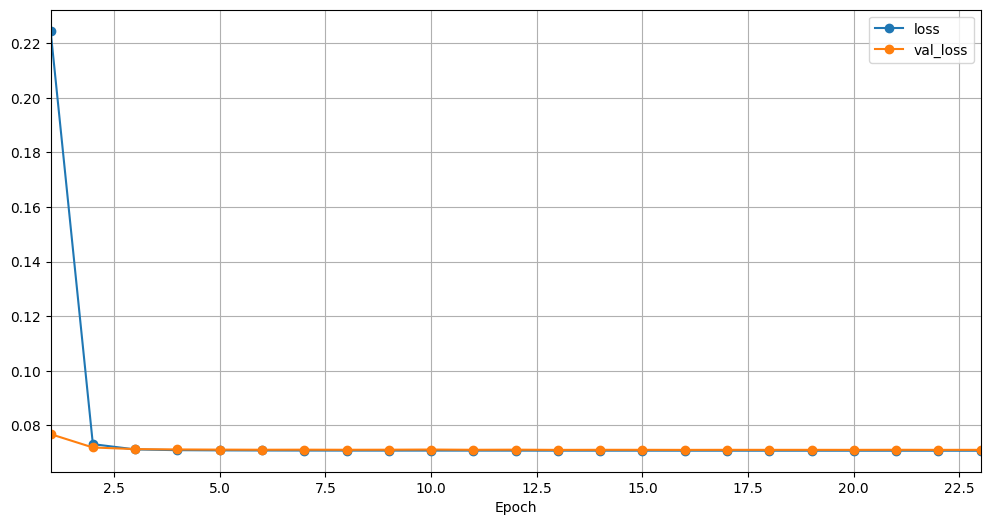

5687/5687 ━━━━━━━━━━━━━━━━━━━━ 5s 860us/step
1422/1422 ━━━━━━━━━━━━━━━━━━━━ 1s 827us/step
Entrenando: VAE-2
Arquitectura: 29-32-16-4
Activación: relu
Épocas: 100
Epoch 1/100
711/711 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.1593 - val_loss: 0.0737
Epoch 2/100
711/711 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0719 - val_loss: 0.0717
Epoch 3/100
711/711 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0711 - val_loss: 0.0713
Epoch 4/100
711/711 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0710 - val_loss: 0.0712
Epoch 5/100
711/711 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0709 - val_loss: 0.0711
Epoch 6/100
711/711 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0709 - val_loss: 0.0711
Epoch 7/100
711/711 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0708 - val_loss: 0.0712
Epoch 8/100
711/711 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0708 - val_loss: 0.0711
Epoch 9/100
711/711 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0708 - val_loss: 0.0711
Epoch 10/100
711/711 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step -

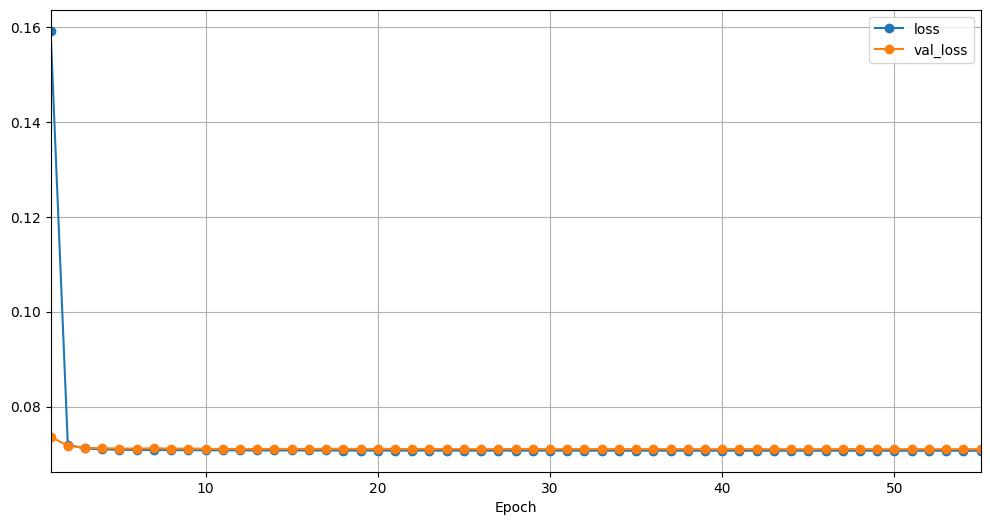

5687/5687 ━━━━━━━━━━━━━━━━━━━━ 5s 850us/step
1422/1422 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
Entrenando: VAE-3
Arquitectura: 29-64-32-8
Activación: relu
Épocas: 100
Epoch 1/100
711/711 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.1269 - val_loss: 0.0730
Epoch 2/100
711/711 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0717 - val_loss: 0.0717
Epoch 3/100
711/711 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0711 - val_loss: 0.0713
Epoch 4/100
711/711 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0710 - val_loss: 0.0713
Epoch 5/100
711/711 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0709 - val_loss: 0.0712
Epoch 6/100
711/711 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.0709 - val_loss: 0.0712
Epoch 7/100
711/711 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0709 - val_loss: 0.0713
Epoch 8/100
711/711 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0708 - val_loss: 0.0711
Epoch 9/100
711/711 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0708 - val_loss: 0.0711
Epoch 10/100
711/711 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - l

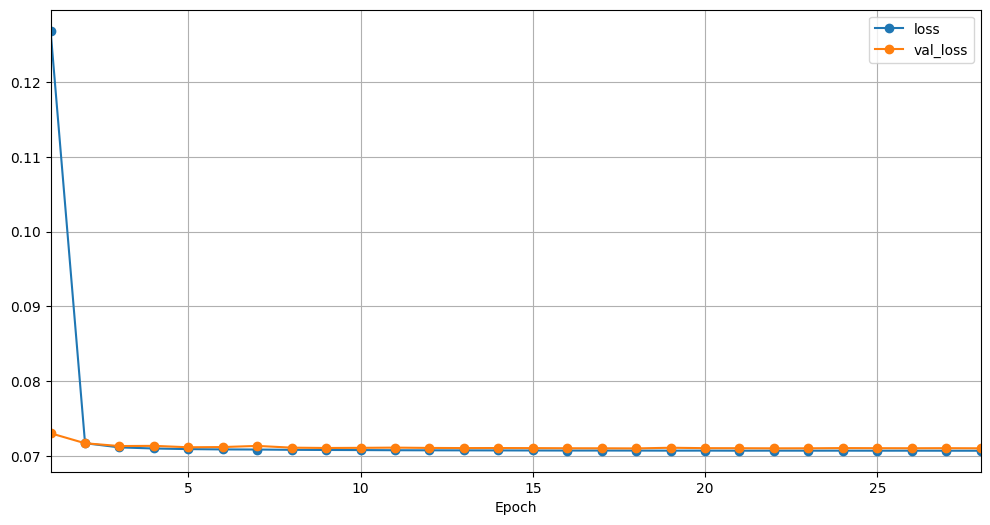

5687/5687 ━━━━━━━━━━━━━━━━━━━━ 5s 923us/step
1422/1422 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step


,Modelo,Arquitectura,Activación,Épocas configuradas,Épocas entrenadas,MAE Train,MAE Val,MSE Train,MSE Val
0,VAE-1,29-16-8-2,relu,50,23,0.030208,0.030257,0.002438,0.002449
1,VAE-2,29-32-16-4,relu,100,55,0.030160,0.030209,0.002437,0.002448
2,VAE-3,29-64-32-8,relu,100,28,0.030170,0.030219,0.002437,0.002449


In [8]:
# ============================================================
# PASO 1 - Entrenamiento y comparación de 3 configuraciones VAE
# Compatible con Keras 3
# ============================================================

input_dim = X_train_normal.shape[1]
results = []
trained_models = {}


# ------------------------------------------------------------
# Capa de muestreo del espacio latente
# ------------------------------------------------------------
class Sampling(layers.Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        epsilon = tf.random.normal(shape=tf.shape(z_mean))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon


# ------------------------------------------------------------
# Clase VAE personalizada
# ------------------------------------------------------------
class VAE(Model):
    def __init__(self, encoder, decoder, input_dim, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.input_dim = input_dim

    def call(self, inputs):
        z_mean, z_log_var, z = self.encoder(inputs)
        reconstruction = self.decoder(z)

        reconstruction_loss = tf.reduce_mean(
            tf.reduce_sum(
                tf.square(inputs - reconstruction),
                axis=1
            )
        )

        kl_loss = -0.5 * tf.reduce_mean(
            tf.reduce_sum(
                1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var),
                axis=1
            )
        )

        total_loss = reconstruction_loss + kl_loss
        self.add_loss(total_loss)

        return reconstruction


# ------------------------------------------------------------
# Función para construir el VAE
# ------------------------------------------------------------
def build_vae(input_dim, hidden_layers, latent_dim, activation='relu'):

    # Encoder
    encoder_inputs = Input(shape=(input_dim,))
    x = encoder_inputs

    for units in hidden_layers:
        x = Dense(units, activation=activation)(x)

    z_mean = Dense(latent_dim, name="z_mean")(x)
    z_log_var = Dense(latent_dim, name="z_log_var")(x)
    z = Sampling(name="z")([z_mean, z_log_var])

    encoder = Model(
        encoder_inputs,
        [z_mean, z_log_var, z],
        name="encoder"
    )

    # Decoder
    latent_inputs = Input(shape=(latent_dim,))
    x = latent_inputs

    for units in reversed(hidden_layers):
        x = Dense(units, activation=activation)(x)

    decoder_outputs = Dense(input_dim, activation="sigmoid")(x)

    decoder = Model(
        latent_inputs,
        decoder_outputs,
        name="decoder"
    )

    # VAE
    vae = VAE(
        encoder=encoder,
        decoder=decoder,
        input_dim=input_dim,
        name="vae"
    )

    vae.compile(optimizer="adam")

    return vae, encoder, decoder


# ------------------------------------------------------------
# Configuraciones a probar
# ------------------------------------------------------------
configs = [
    {
        "modelo": "VAE-1",
        "arquitectura": "29-16-8-2",
        "hidden_layers": [16, 8],
        "latent_dim": 2,
        "activation": "relu",
        "epochs": 50,
        "batch_size": 256
    },
    {
        "modelo": "VAE-2",
        "arquitectura": "29-32-16-4",
        "hidden_layers": [32, 16],
        "latent_dim": 4,
        "activation": "relu",
        "epochs": 100,
        "batch_size": 256
    },
    {
        "modelo": "VAE-3",
        "arquitectura": "29-64-32-8",
        "hidden_layers": [64, 32],
        "latent_dim": 8,
        "activation": "relu",
        "epochs": 100,
        "batch_size": 256
    }
]


# ------------------------------------------------------------
# Entrenamiento de las 3 configuraciones
# ------------------------------------------------------------
for config in configs:

    print("==========================================")
    print("Entrenando:", config["modelo"])
    print("Arquitectura:", config["arquitectura"])
    print("Activación:", config["activation"])
    print("Épocas:", config["epochs"])
    print("==========================================")

    vae, encoder, decoder = build_vae(
        input_dim=input_dim,
        hidden_layers=config["hidden_layers"],
        latent_dim=config["latent_dim"],
        activation=config["activation"]
    )

    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True
    )

    history = vae.fit(
        X_train_normal,
        X_train_normal,
        validation_data=(X_val_normal, X_val_normal),
        epochs=config["epochs"],
        batch_size=config["batch_size"],
        callbacks=[early_stop],
        verbose=1
    )

    plot_history(history)

    # Reconstrucción en train y validación
    X_train_pred = vae.predict(X_train_normal)
    X_val_pred = vae.predict(X_val_normal)

    # Métricas MAE y MSE
    mae_train, mse_train = evaluate_reconstruction(
        X_train_normal,
        X_train_pred
    )

    mae_val, mse_val = evaluate_reconstruction(
        X_val_normal,
        X_val_pred
    )

    results.append({
        "Modelo": config["modelo"],
        "Arquitectura": config["arquitectura"],
        "Activación": config["activation"],
        "Épocas configuradas": config["epochs"],
        "Épocas entrenadas": len(history.history["loss"]),
        "MAE Train": mae_train,
        "MAE Val": mae_val,
        "MSE Train": mse_train,
        "MSE Val": mse_val
    })

    trained_models[config["modelo"]] = {
        "vae": vae,
        "encoder": encoder,
        "decoder": decoder,
        "history": history,
        "config": config
    }


# ------------------------------------------------------------
# Tabla comparativa
# ------------------------------------------------------------
results_df = DataFrame(results)
results_df

In [9]:
# ============================================================
# Selección del mejor modelo
# ============================================================

results_df_sorted = results_df.sort_values(by="MSE Val", ascending=True)
results_df_sorted

,Modelo,Arquitectura,Activación,Épocas configuradas,Épocas entrenadas,MAE Train,MAE Val,MSE Train,MSE Val
1,VAE-2,29-32-16-4,relu,100,55,0.030160,0.030209,0.002437,0.002448
2,VAE-3,29-64-32-8,relu,100,28,0.030170,0.030219,0.002437,0.002449
0,VAE-1,29-16-8-2,relu,50,23,0.030208,0.030257,0.002438,0.002449


In [10]:
best_model_name = results_df_sorted.iloc[0]["Modelo"]
best_model = trained_models[best_model_name]["vae"]

print("Mejor modelo seleccionado:", best_model_name)
print("Motivo: menor MSE de validación entre las configuraciones probadas.")

Mejor modelo seleccionado: VAE-2
Motivo: menor MSE de validación entre las configuraciones probadas.


### Selección del mejor modelo

A partir de las tres configuraciones evaluadas, se selecciona el modelo **VAE-2** como mejor opción.

Aunque los tres modelos presentan resultados muy similares, **VAE-2** obtiene el menor error de validación:

- MAE Validación: 0.030209
- MSE Validación: 0.002448

Además, la diferencia entre entrenamiento y validación es baja, lo que indica que el modelo generaliza correctamente sobre transacciones normales no vistas durante el entrenamiento.

Por lo tanto, se utilizará **VAE-2** para la búsqueda del umbral óptimo y la evaluación final del modelo de detección de fraude.

### Comparación de configuraciones

| Modelo | MAE Train | MAE Val | MSE Train | MSE Val |
|---------|-----------|----------|-----------|----------|
| VAE-1 | 0.030208 | 0.030257 | 0.002438 | 0.002449 |
| VAE-2 | 0.030160 | 0.030209 | 0.002437 | 0.002448 |
| VAE-3 | 0.030170 | 0.030219 | 0.002437 | 0.002449 |

La configuración VAE-2 obtuvo el menor error de validación, por lo que fue seleccionada para las siguientes etapas.

## Paso 2 (3 puntos):

Con el mejor modelo entrenado en el Paso 1, encuentre el mejor umbral para el error tal que pueda maximizar la métrica F1-Score en el conjunto de validación.

In [11]:
# ============================================================
# PASO 2
# Búsqueda del mejor threshold usando F1-score
# ============================================================

# Reconstrucción del conjunto de validación
X_val_pred = best_model.predict(X_val)

# Error de reconstrucción
val_errors = reconstruction_error(
    X_val,
    X_val_pred
)

print("Error mínimo:", val_errors.min())
print("Error máximo:", val_errors.max())
print("Número de muestras:", len(val_errors))

1425/1425 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
Error mínimo: 0.0003945429259215167
Error máximo: 0.12943794392307054
Número de muestras: 45569


In [12]:
# ============================================================
# Evaluación de múltiples thresholds
# ============================================================

thresholds = np.linspace(
    val_errors.min(),
    val_errors.max(),
    200
)

best_threshold = None
best_f1 = -1

threshold_results = []

for threshold in thresholds:

    y_pred = (val_errors > threshold).astype(int)

    f1 = f1_score(
        y_val,
        y_pred
    )

    threshold_results.append({
        "Threshold": threshold,
        "F1": f1
    })

    if f1 > best_f1:
        best_f1 = f1
        best_threshold = threshold

print("================================")
print("MEJOR THRESHOLD")
print("================================")
print("Threshold :", best_threshold)
print("F1 Score  :", best_f1)

MEJOR THRESHOLD
Threshold : 0.02698137428714318
F1 Score  : 0.5066666666666667


In [13]:
threshold_df = DataFrame(threshold_results)

threshold_df.sort_values(
    by="F1",
    ascending=False
).head(10)

,Threshold,F1
41,0.026981,0.506667
40,0.026333,0.500000
42,0.027630,0.496644
44,0.028927,0.496552
47,0.030872,0.496454
48,0.031521,0.496454
46,0.030224,0.492958
45,0.029575,0.492958
39,0.025684,0.487179
43,0.028278,0.486486


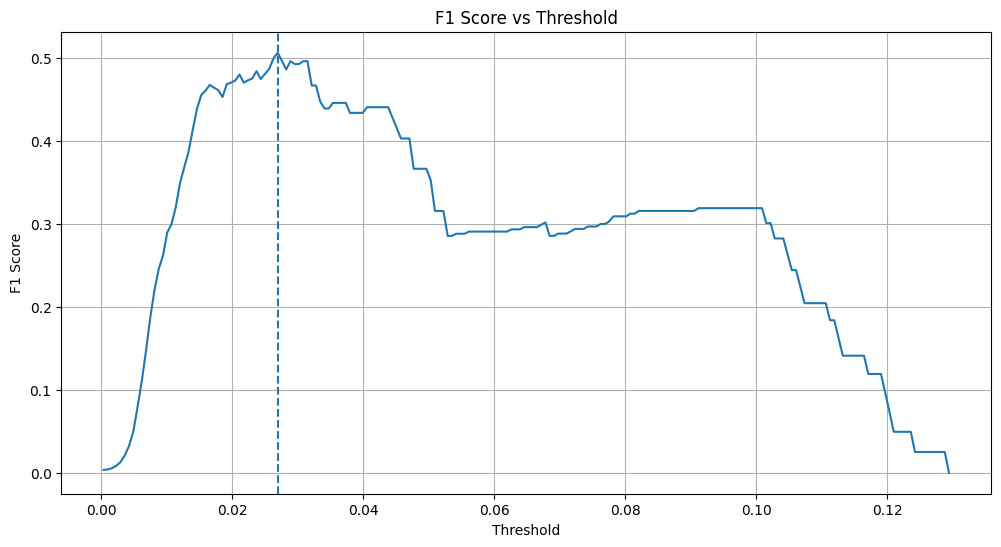

In [14]:
plt.figure(figsize=(12,6))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["F1"]
)

plt.axvline(
    best_threshold,
    linestyle="--"
)

plt.xlabel("Threshold")
plt.ylabel("F1 Score")
plt.title("F1 Score vs Threshold")
plt.grid()

plt.show()

In [15]:
print(f"Best Threshold = {best_threshold:.8f}")
print(f"Best F1 Score  = {best_f1:.4f}")

Best Threshold = 0.02698137
Best F1 Score  = 0.5067


### Resultado Paso 2

Con el modelo seleccionado **VAE-2**, se calculó el error de reconstrucción sobre el conjunto de validación completo.

Luego se evaluaron distintos valores de threshold y se seleccionó el que maximizó la métrica F1-Score.

El mejor resultado obtenido fue:

- **Best Threshold:** 0.02698137
- **Best F1-Score:** 0.5067

Este umbral será utilizado en el Paso 3 para clasificar las transacciones del conjunto de prueba como normales o fraudulentas.

## Paso 3 (2 puntos):

Usando el modelo entrenado y el umbral encontrado en los pasos anteriores, evaluar el modelo con el conjunto de prueba y entregue la matriz de confusión y el __classification_report__.

In [16]:
# ============================================================
# PASO 3
# Evaluación final sobre conjunto de prueba
# ============================================================

# Reconstrucción del conjunto de prueba
X_test_pred = best_model.predict(X_test)

# Error de reconstrucción
test_errors = reconstruction_error(
    X_test,
    X_test_pred
)

# Clasificación usando el mejor threshold
y_pred_test = (
    test_errors > best_threshold
).astype(int)

print("Threshold utilizado:", best_threshold)

print("\nDistribución predicciones:")
print(DataFrame(y_pred_test).value_counts())

1781/1781 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step
Threshold utilizado: 0.02698137428714318

Distribución predicciones:
0
0    56893
1       69
Name: count, dtype: int64


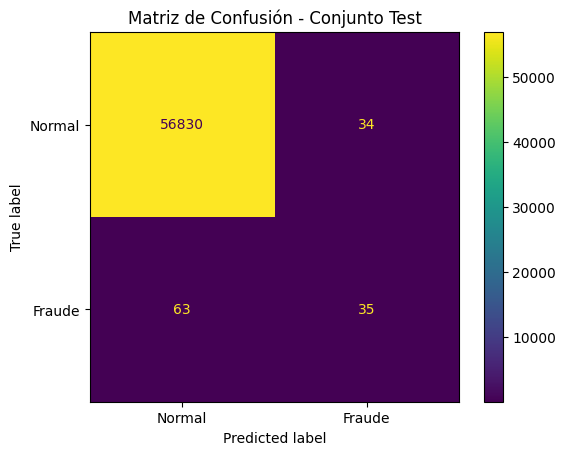

In [17]:
# ============================================================
# Matriz de confusión
# ============================================================

cm = confusion_matrix(
    y_test,
    y_pred_test
)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Normal", "Fraude"]
).plot()

plt.title("Matriz de Confusión - Conjunto Test")
plt.show()

In [18]:
# ============================================================
# Classification Report
# ============================================================

report = classification_report(
    y_test,
    y_pred_test
)

print(report)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.51      0.36      0.42        98

    accuracy                           1.00     56962
   macro avg       0.75      0.68      0.71     56962
weighted avg       1.00      1.00      1.00     56962



In [19]:
from sklearn.metrics import accuracy_score

print("Accuracy :", accuracy_score(y_test, y_pred_test))
print("F1 Score :", f1_score(y_test, y_pred_test))

Accuracy : 0.9982971103542713
F1 Score : 0.41916167664670656


# Conclusión Final

En este trabajo se implementó un **Autoencoder Variacional (VAE)** para abordar el problema de detección de fraude en transacciones de tarjetas de crédito mediante un enfoque de detección de anomalías.

Durante el Paso 1 se evaluaron tres configuraciones distintas del VAE variando la arquitectura, el tamaño del espacio latente y el número de neuronas ocultas. La comparación se realizó utilizando las métricas MAE y MSE sobre los conjuntos de entrenamiento y validación. La configuración **VAE-2 (29-32-16-4)** obtuvo el mejor desempeño, alcanzando el menor error de validación (MSE = 0.002448), por lo que fue seleccionada para las etapas posteriores.

En el Paso 2 se calculó el error de reconstrucción sobre el conjunto de validación y se evaluaron múltiples valores de umbral (threshold). El mejor resultado se obtuvo con un umbral de **0.02698137**, logrando un **F1-Score de 0.5067** sobre el conjunto de validación.

Finalmente, en el Paso 3 se evaluó el modelo sobre el conjunto de prueba utilizando el umbral seleccionado. Los resultados obtenidos fueron:

* Accuracy: **99.83%**
* Precision (Fraude): **0.51**
* Recall (Fraude): **0.36**
* F1-Score (Fraude): **0.42**

La matriz de confusión mostró los siguientes resultados:

|        | Predicho Normal | Predicho Fraude |
| ------ | --------------: | --------------: |
| Normal |          56.830 |              34 |
| Fraude |              63 |              35 |

Estos resultados indican que el modelo es altamente efectivo para identificar transacciones normales, generando un número reducido de falsas alarmas. Asimismo, logró detectar 35 de las 98 transacciones fraudulentas presentes en el conjunto de prueba.

Debido al fuerte desbalance existente entre clases, la métrica Accuracy por sí sola no representa adecuadamente el desempeño del sistema. Por esta razón, el análisis se centró principalmente en el F1-Score, que combina precisión y sensibilidad en una única medida.

En conclusión, el Autoencoder Variacional demostró ser una alternativa viable para la detección de fraude basada en anomalías, permitiendo modelar el comportamiento normal de las transacciones y detectar patrones inusuales mediante el error de reconstrucción. Si bien existe espacio para mejorar la sensibilidad del modelo, los resultados obtenidos validan la efectividad del enfoque propuesto para este tipo de problema.



Tabla Resumen
| Paso            | Resultado  |
| --------------- | ---------- |
| Mejor Modelo    | VAE-2      |
| Mejor Threshold | 0.02698137 |
| F1 Validation   | 0.5067     |
| F1 Test         | 0.4192     |
| Accuracy Test   | 99.83%     |
